In [53]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf

In [54]:
image_path = "C:/Users/prate/Downloads/train/train/"
mask_path = "C:/Users/prate/Downloads/train_cleaned/train_cleaned/"

images = []
masks = []

files = os.listdir(image_path)

IMG_HEIGHT = 256
IMG_WIDTH = 256

for file in files:
    img = cv2.imread(image_path + file, cv2.IMREAD_GRAYSCALE)
    mask = cv2.imread(mask_path + file, cv2.IMREAD_GRAYSCALE)

    img = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT))
    mask = cv2.resize(mask, (IMG_WIDTH, IMG_HEIGHT))

    img = img / 255.0
    mask = mask / 255.0

    images.append(img)
    masks.append(mask)

images = np.array(images)
masks = np.array(masks)

print(images.shape)

(144, 256, 256)


In [55]:
images = images.reshape(-1, 256, 256, 1)
masks = masks.reshape(-1, 256, 256, 1)

In [56]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    images, masks, test_size=0.2, random_state=42
)

print(X_train.shape, X_test.shape)


(115, 256, 256, 1) (29, 256, 256, 1)


In [57]:
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model

input_img = Input(shape=(256, 256, 1))

# Encoder
x = Conv2D(128, (3,3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2,2), padding='same')(x)

x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
x = MaxPooling2D((2,2), padding='same')(x)

x = Conv2D(32, (3,3), activation='relu', padding='same')(x)

# Decoder
x = Conv2D(32, (3,3), activation='relu', padding='same')(x)

x = UpSampling2D((2,2))(x)
x = Conv2D(64, (3,3), activation='relu', padding='same')(x)

x = UpSampling2D((2,2))(x)
x = Conv2D(128, (3,3), activation='relu', padding='same')(x)

decoded = Conv2D(1, (3,3), activation='sigmoid', padding='same')(x)

In [58]:
autoencoder.compile(optimizer='adam', loss='mae')

In [59]:
autoencoder.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=2,
    validation_data=(X_test, y_test)
)

Epoch 1/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 14s 167ms/step - loss: 0.0511 - val_loss: 0.0518
Epoch 2/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 10s 164ms/step - loss: 0.0499 - val_loss: 0.0515
Epoch 3/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 9s 146ms/step - loss: 0.0499 - val_loss: 0.0514
Epoch 4/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 9s 162ms/step - loss: 0.0498 - val_loss: 0.0523
Epoch 5/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 10s 163ms/step - loss: 0.0501 - val_loss: 0.0513
Epoch 6/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 10s 161ms/step - loss: 0.0499 - val_loss: 0.0511
Epoch 7/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 10s 161ms/step - loss: 0.0494 - val_loss: 0.0508
Epoch 8/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 9s 162ms/step - loss: 0.0491 - val_loss: 0.0505
Epoch 9/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 9s 148ms/step - loss: 0.0491 - val_loss: 0.0506
Epoch 10/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 9s 162ms/step - loss: 0.0491 - val_loss: 0.0513
Epoch 11/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 9s 145ms/step - loss: 0.0489 - val_loss: 0.0502
Epoch 12/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 11s 163m

In [60]:
decoded_imgs = autoencoder.predict(X_test[:5])

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 583ms/step


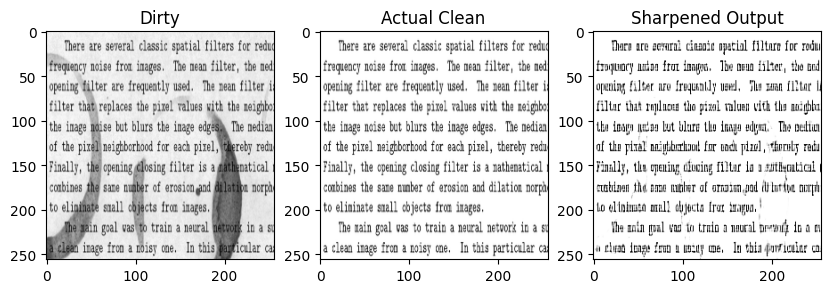

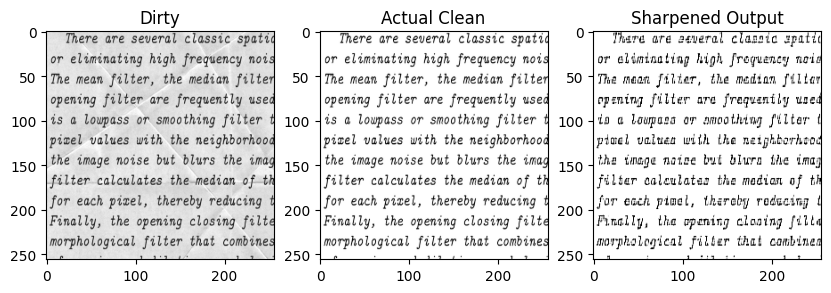

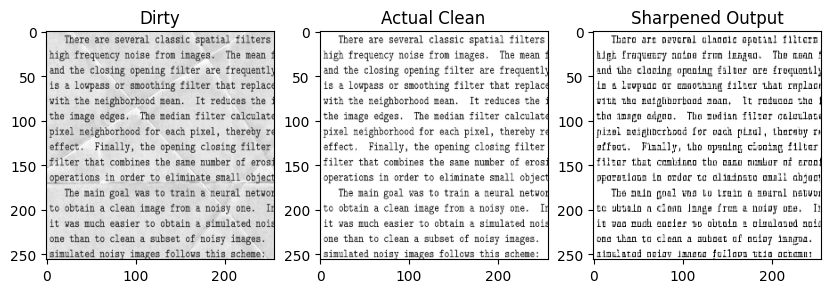

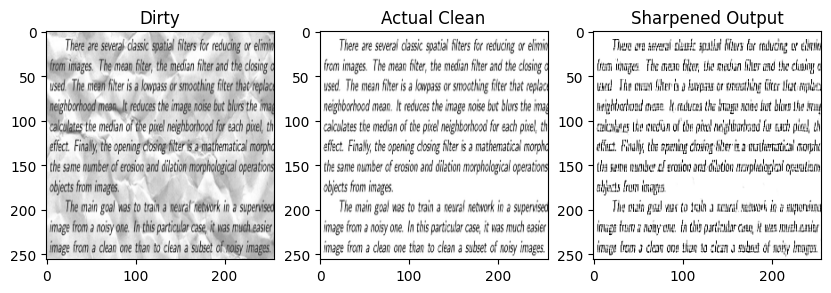

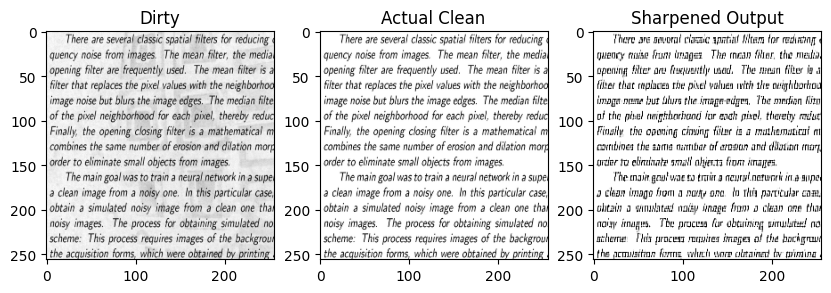

In [67]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

for i in range(5):
    img = decoded_imgs[i].reshape(256,256)

    # First blur
    blur = cv2.GaussianBlur(img, (0,0), 1)

    # Then sharpen
    sharpened = cv2.addWeighted(img, 1.8, blur, -0.8, 0)

    # Clip values (important)
    sharpened = np.clip(sharpened, 0, 1)

    plt.figure(figsize=(10,3))

    plt.subplot(1,3,1)
    plt.title("Dirty")
    plt.imshow(X_test[i].reshape(256,256), cmap='gray')

    plt.subplot(1,3,2)
    plt.title("Actual Clean")
    plt.imshow(y_test[i].reshape(256,256), cmap='gray')

    plt.subplot(1,3,3)
    plt.title("Sharpened Output")
    plt.imshow(sharpened, cmap='gray')

    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step


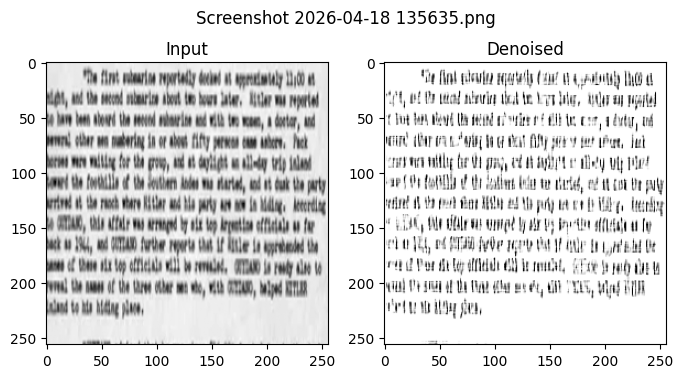

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step


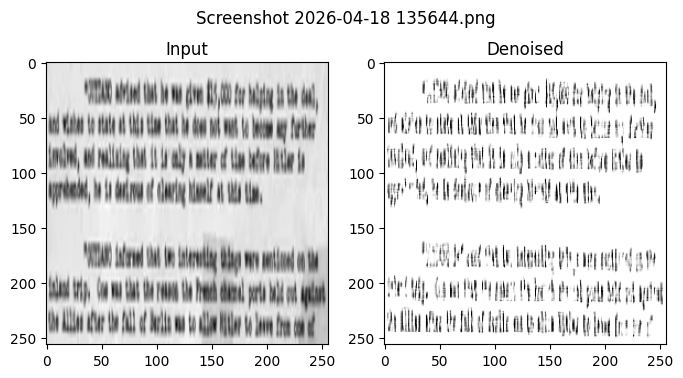

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step


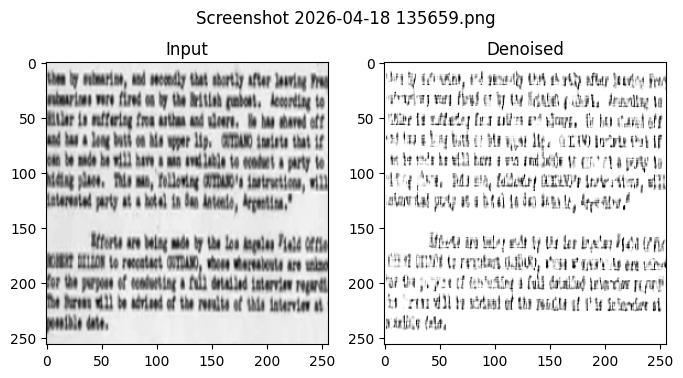

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step


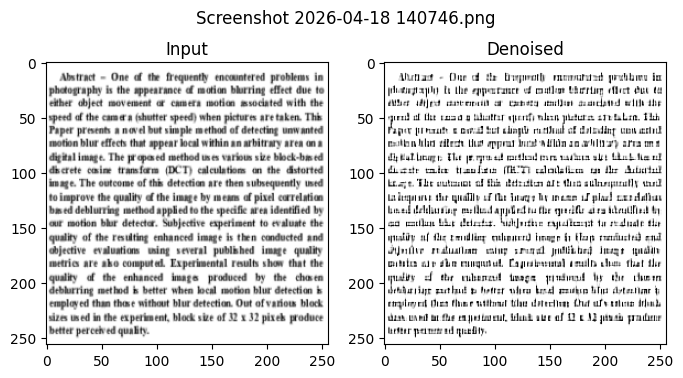

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step


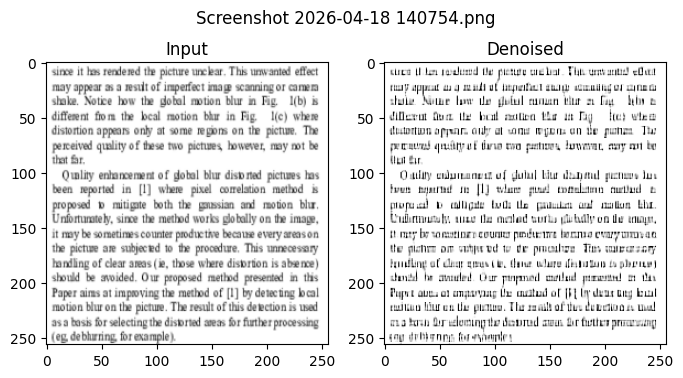

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step


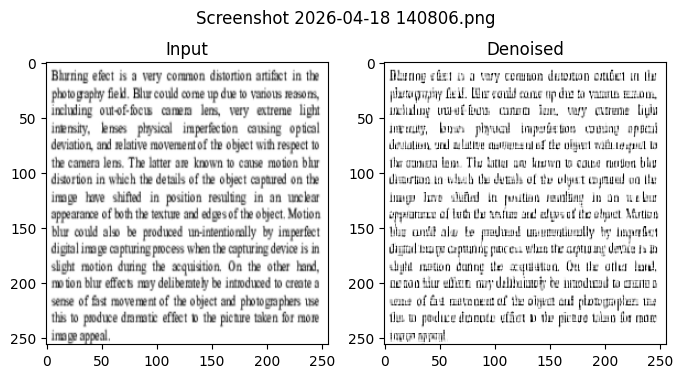

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step


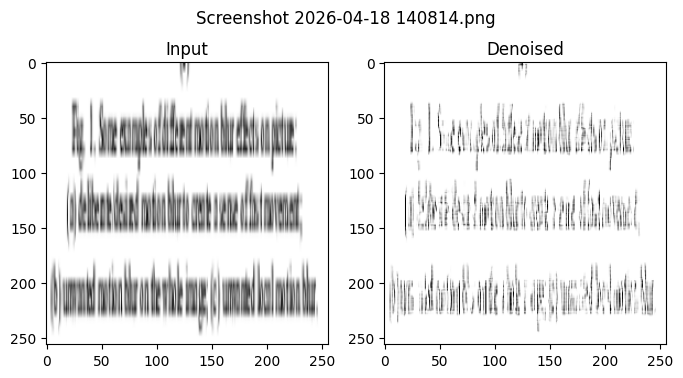

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step


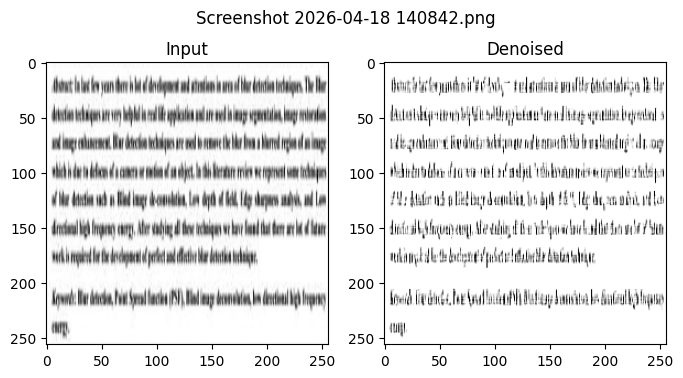

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step


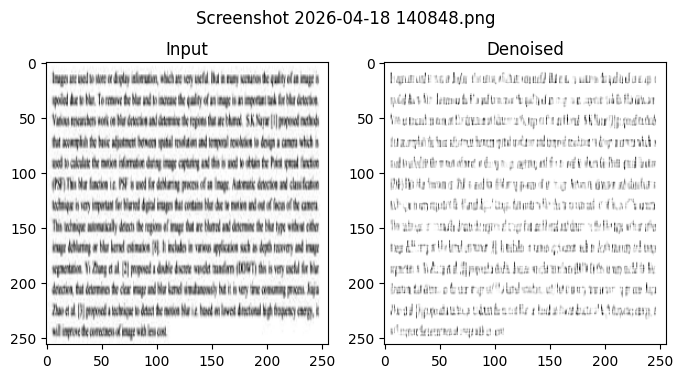

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step


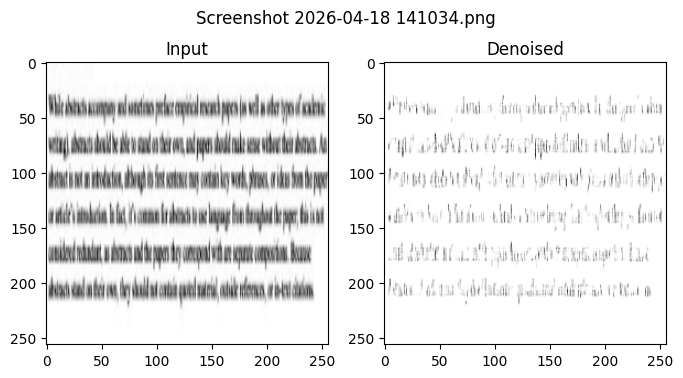

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step


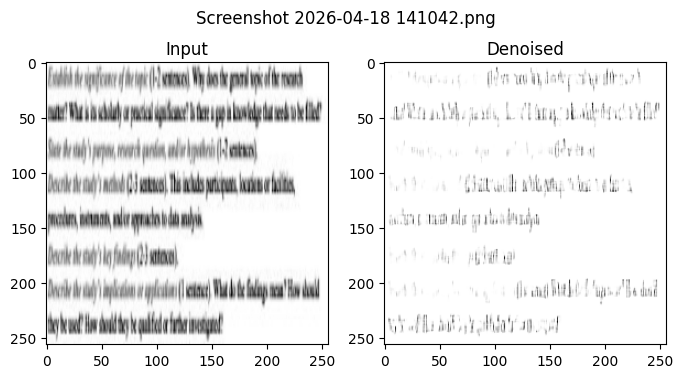

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step


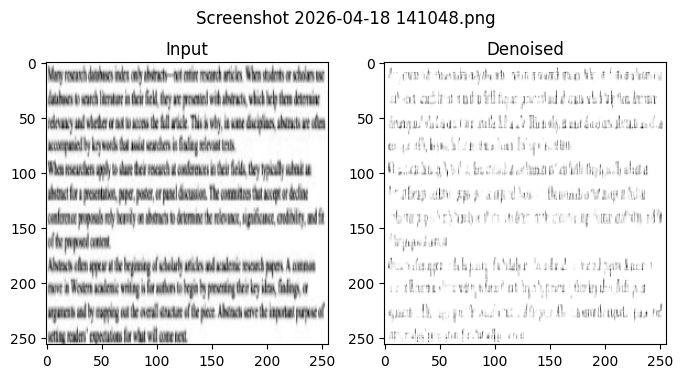

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step


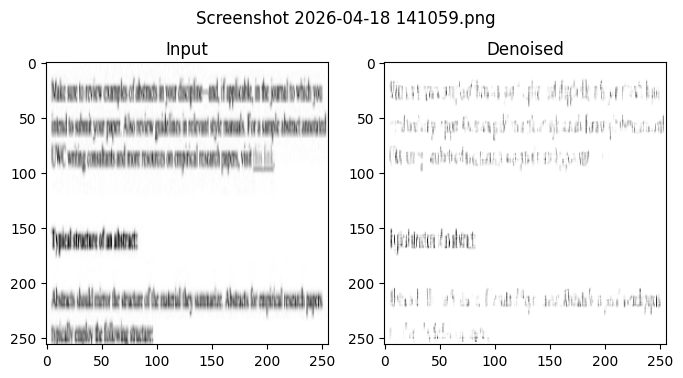

In [72]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

test_path = "C:/Users/prate/OneDrive/Desktop/SS_DATA1/"

files = os.listdir(test_path)

for file in files:
    img = cv2.imread(test_path + file, cv2.IMREAD_GRAYSCALE)
    
    if img is None:
        print("Skipping:", file)
        continue

    img = cv2.resize(img, (256,256))
    img = img / 255.0

    img_input = img.reshape(1, 256, 256, 1)

    # prediction
    output = autoencoder.predict(img_input)
    result = output[0].reshape(256,256)

    # sharpening
    blur = cv2.GaussianBlur(result, (0,0), 1)
    sharpened = cv2.addWeighted(result, 1.8, blur, -0.8, 0)
    sharpened = np.clip(sharpened, 0, 1)

    # display
    plt.figure(figsize=(8,4))

    plt.subplot(1,2,1)
    plt.title("Input")
    plt.imshow(img, cmap='gray')

    plt.subplot(1,2,2)
    plt.title("Denoised")
    plt.imshow(sharpened, cmap='gray')

    plt.suptitle(file)
    plt.show()